In [1]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Default figure size
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

df = pd.read_csv("Food_Delivery_Customer_Order.csv")
print("Dataset loaded successfully!")



Libraries imported successfully!
Dataset loaded successfully!


In [2]:
#1. DATASET
# ================================================================

print("\nFirst 5 rows of the dataset:")
display(df.head())


# Show last 5 rows
print("\nLast 5 rows of the dataset:")
display(df.tail())



First 5 rows of the dataset:


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,distance_km,traffic,weather
0,4601,2261,Amy Ruth's,Southern,12.23,Weekday,NaN,32.0,33.0,6.2,Heavy,Cloudy
1,2073,3769,Otto Enoteca Pizzeria,Italian,29.05,Weekend,5,24.0,18.0,3.8,Moderate,Cloudy
2,8315,1971,Shake Shack,American,16.98,Weekend,NaN,22.0,21.0,8.2,Low,Clear
3,7833,5229,TAO,Japanese,12.71,Weekend,3,22.0,17.0,5.2,Low,Clear
4,2059,2236,Blue Ribbon Sushi,Japanese,16.49,Weekend,3,24.0,30.0,5.7,Heavy,Clear



Last 5 rows of the dataset:


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,distance_km,traffic,weather
9995,5876,2374,The Kati Roll Company,Indian,16.83,Weekend,4,26.0,20.0,5.2,Moderate,Clear
9996,1168,5302,Han Dynasty,Chinese,29.15,Weekday,NaN,20.0,24.0,3.9,Moderate,Clear
9997,8574,6236,Rubirosa,Italian,-50.00,Weekend,NaN,33.0,20.0,2.9,Heavy,Cloudy
9998,7945,6786,Shake Shack,American,13.97,Weekend,5,35.0,27.0,3.6,Heavy,Rainy
9999,3106,6040,Shake Shack,American,16.25,Weekend,Not given,27.0,23.0,5.6,Moderate,Clear


In [3]:
# 2. DATASET OVERVIEW


print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Information:")
df.info()



Dataset Shape:
(10000, 12)

Column Names:
['order_id', 'customer_id', 'restaurant_name', 'cuisine_type', 'cost_of_the_order', 'day_of_the_week', 'rating', 'food_preparation_time', 'delivery_time', 'distance_km', 'traffic', 'weather']

Data Types:


,Data Type
order_id,int64
customer_id,int64
restaurant_name,str
cuisine_type,str
cost_of_the_order,float64
day_of_the_week,str
rating,str
food_preparation_time,float64
delivery_time,float64
distance_km,float64



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               10000 non-null  int64  
 1   customer_id            10000 non-null  int64  
 2   restaurant_name        9952 non-null   str    
 3   cuisine_type           9931 non-null   str    
 4   cost_of_the_order      9918 non-null   float64
 5   day_of_the_week        10000 non-null  str    
 6   rating                 6506 non-null   str    
 7   food_preparation_time  9898 non-null   float64
 8   delivery_time          9898 non-null   float64
 9   distance_km            9878 non-null   float64
 10  traffic                9897 non-null   str    
 11  weather                9920 non-null   str    
dtypes: float64(4), int64(2), str(6)
memory usage: 703.2 KB


In [4]:
# 3. STATISTICAL SUMMARY


print("\nStatistical Summary:")
display(df.describe(include="all").T)




Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,10000.0,NaN,NaN,NaN,5006.524,2884.266051,1.0,2511.75,5017.5,7499.25,10000.0
customer_id,10000.0,NaN,NaN,NaN,3982.2191,1734.024549,1002.0,2487.0,3995.0,5464.25,7000.0
restaurant_name,9952,250,Shake Shack,1160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,9931,27,American,3035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,9918.0,NaN,NaN,NaN,17.026544,15.610894,-50.0,12.08,14.41,22.31,398.0
day_of_the_week,10000,4,Weekend,6965,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,6506,6,5,2856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,9898.0,NaN,NaN,NaN,27.440089,4.993509,-5.0,23.0,27.0,31.0,76.0
delivery_time,9898.0,NaN,NaN,NaN,24.334613,6.570529,-10.0,20.0,25.0,28.0,145.0
distance_km,9878.0,NaN,NaN,NaN,5.775541,1.843567,-2.0,4.6,5.8,6.9,29.913851


In [5]:
#4. UNIQUE VALUES IN EACH COLUMN

print("\nNumber of Unique Values in Each Column:")

unique_values = df.nunique().sort_values(ascending=False)

display(unique_values.to_frame("Unique Values"))



Number of Unique Values in Each Column:


,Unique Values
order_id,9850
customer_id,4869
cost_of_the_order,333
restaurant_name,250
distance_km,102
delivery_time,36
food_preparation_time,31
cuisine_type,27
rating,6
traffic,6


In [6]:
# 5. DATA CLEANING
# ------------------------------------------------
# 5.1 CLEAN COLUMN NAMES
# ------------------------------------------------

# Remove spaces from column names
# Convert names to lowercase
# Replace spaces with underscores

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns.tolist())


# ------------------------------------------------
# 5.2REMOVE EXTRA SPACES FROM TEXT DATA
# ------------------------------------------------

# Select only text/string columns
# This version works correctly with newer Pandas versions.
text_columns = df.select_dtypes(include=["str"]).columns

print("Text columns found:")
print(text_columns.tolist())

# Remove unnecessary spaces from the beginning and end
# of values in each text column
for column in text_columns:
    df[column] = df[column].str.strip()

print("\nText columns cleaned successfully.")


Cleaned Column Names:
['order_id', 'customer_id', 'restaurant_name', 'cuisine_type', 'cost_of_the_order', 'day_of_the_week', 'rating', 'food_preparation_time', 'delivery_time', 'distance_km', 'traffic', 'weather']
Text columns found:
['restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating', 'traffic', 'weather']

Text columns cleaned successfully.


In [7]:
# ================================================================
# 6. CHECK MISSING VALUES
# ================================================================

print("\nMissing Values in Each Column:")

missing_values = df.isnull().sum()

display(
    missing_values.to_frame("Missing Count")
)


# ------------------------------------------------
# Calculate missing-value percentage
# ------------------------------------------------

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})

print("\nMissing Value Analysis:")
display(missing_table)


# First convert "Not given" into missing value
df["rating"] = df["rating"].replace(
    ["Not given", "not given", "", "NA", "N/A"],
    np.nan
)

# Then convert rating to numeric
df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)



Missing Values in Each Column:


,Missing Count
order_id,0
customer_id,0
restaurant_name,48
cuisine_type,69
cost_of_the_order,82
day_of_the_week,0
rating,3494
food_preparation_time,102
delivery_time,102
distance_km,122



Missing Value Analysis:


,Missing Count,Missing Percentage
order_id,0,0.00
customer_id,0,0.00
restaurant_name,48,0.48
cuisine_type,69,0.69
cost_of_the_order,82,0.82
day_of_the_week,0,0.00
rating,3494,34.94
food_preparation_time,102,1.02
delivery_time,102,1.02
distance_km,122,1.22


In [8]:
# ================================================================
# 7. HANDLE "NOT GIVEN" IN RATING
# ================================================================

# The dataset contains "Not given" in the rating column.
# This means the customer did not provide a rating.
#
# We convert "Not given" to NaN (missing value).
#
# We DO NOT replace it with 3, 4, or 5 because we do not
# know the actual rating.

if "rating" in df.columns:

    df["rating"] = df["rating"].replace(
        ["Not given", "not given", "", "NA", "N/A"],
        np.nan
    )

    # Convert rating to numeric
    df["rating"] = pd.to_numeric(
        df["rating"],
        errors="coerce"
    )

    print("\nRating values after cleaning:")
    print(df["rating"].value_counts(dropna=False))




Rating values after cleaning:
rating
NaN    4388
5.0    2856
4.0    1872
3.0     863
0.0      11
6.0      10
Name: count, dtype: int64


In [9]:
# ================================================================
# 10. CONVERT NUMERICAL COLUMNS TO NUMERIC DATA TYPE
# ================================================================

numeric_columns = [
    "order_id",
    "customer_id",
    "cost_of_the_order",
    "food_preparation_time",
    "delivery_time",
    "distance_km"
]

for column in numeric_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

print("\nNumerical columns converted successfully.")




Numerical columns converted successfully.


In [10]:
# ================================================================
# 8. CHECK DUPLICATES
# ================================================================

duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate rows:", duplicate_count)


# ------------------------------------------------
# Display duplicate rows
# ------------------------------------------------

if duplicate_count > 0:

    print("\nDuplicate Rows:")
    display(
        df[df.duplicated(keep=False)]
    )

else:

    print("No duplicate rows found.")


# ------------------------------------------------
# Remove duplicates if they exist
# ------------------------------------------------

if duplicate_count > 0:

    df = df.drop_duplicates()

    # Reset row index
    df = df.reset_index(drop=True)

    print("\nDuplicates removed.")

else:

    print("\nNo duplicates needed to be removed.")



Number of duplicate rows: 150

Duplicate Rows:


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,distance_km,traffic,weather
17,5376,5040,Room Service,Thai,12.23,Weekend,NaN,35.0,16.0,5.1,Low,Cloudy
20,5550,5105,RedFarm Broadway,Chinese,12.90,Weekday,3.0,29.0,29.0,8.2,Moderate,Clear
25,2905,6541,Saravanaa Bhavan,Indian,12.13,Weekday,NaN,32.0,26.0,6.2,Moderate,Cloudy
67,9567,5349,Yama Japanese Restaurant,Japanese,-50.00,Weekend,NaN,30.0,16.0,3.3,Moderate,Clear
213,7646,4841,Blue Ribbon Sushi Bar & Grill,Japanese,12.08,Weekday,5.0,29.0,24.0,5.7,Moderate,Clear
...,...,...,...,...,...,...,...,...,...,...,...,...
9817,4835,1691,Mamoun's Falafel,Mediterranean,14.41,Weekend,NaN,33.0,26.0,6.4,Moderate,Clear
9850,5890,4584,Rubirosa,Italian,24.20,Weekend,5.0,31.0,15.0,5.5,Low,Clear
9853,5292,2524,Coppola's East,Italian,13.05,Weekend,NaN,32.0,16.0,3.9,Moderate,Clear
9856,55,3576,Sushi of Gari,Japanese,16.01,Weekend,NaN,33.0,19.0,6.1,Low,Clear



Duplicates removed.


In [11]:
# ================================================================
# 9. CHECK INVALID / NEGATIVE VALUES
# ================================================================

print("\nChecking negative values:")

for column in numeric_columns:

    if column in df.columns:

        negative_count = (
            df[column] < 0
        ).sum()

        print(
            column,
            ":",
            negative_count,
            "negative values"
        )





Checking negative values:
order_id : 0 negative values
customer_id : 0 negative values
cost_of_the_order : 10 negative values
food_preparation_time : 10 negative values
delivery_time : 10 negative values
distance_km : 10 negative values


In [12]:
# ================================================================
# 10. CHECK RATING RANGE
# ================================================================

if "rating" in df.columns:

    invalid_ratings = df[
        (df["rating"] < 1) |
        (df["rating"] > 5)
    ]

    print(
        "\nNumber of invalid ratings:",
        len(invalid_ratings)
    )

    if len(invalid_ratings) > 0:
        display(invalid_ratings)





Number of invalid ratings: 20


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,distance_km,traffic,weather
537,7011,3049,Sushi of Gari 46,Japanese,14.60,Weekday,0.0,24.0,24.0,5.8,Moderate,Clear
1226,7874,2307,Cafe Mogador,Middle Eastern,15.91,Weekend,0.0,32.0,15.0,3.0,Moderate,Clear
1741,7205,2208,Barbounia,Mediterranean,5.97,Weekday,0.0,33.0,30.0,5.7,Heavy,Cloudy
1746,100,6882,The Meatball Shop,Italian,24.20,Weekend,6.0,24.0,24.0,7.1,Low,Clear
2091,5704,6039,Shake Shack,American,8.34,Weekend,0.0,21.0,30.0,5.9,Moderate,Rainy
2449,5289,5412,Jack's Wife Freda,Mediterranean,25.17,Weekday,6.0,31.0,25.0,5.9,Moderate,Clear
2558,6911,4013,Sushi of Gari Tribeca,Japanese,12.18,Weekend,0.0,35.0,NaN,5.7,Low,Clear
2615,5734,1104,Hill Country Fried Chicken,Southern,14.84,Weekend,6.0,21.0,21.0,4.4,Moderate,Clear
2634,155,3849,Blue Ribbon Fried Chicken,American,6.45,Weekend,6.0,30.0,24.0,5.7,Moderate,Clear
3251,6655,1076,Barbounia,Mediterranean,20.18,Weekend,6.0,29.0,19.0,4.8,Moderate,Clear


In [13]:
# ================================================================
# 11. FINAL CLEANING CHECK
# ================================================================

print("\n================================================")
print("FINAL DATA CLEANING CHECK")
print("================================================")

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
display(
    df.isnull().sum().to_frame("Missing Count")
)

print(
    "\nDuplicate Rows:",
    df.duplicated().sum()
)

print("\nFinal Data Types:")
display(df.dtypes.to_frame("Data Type"))





FINAL DATA CLEANING CHECK

Final Dataset Shape:
(9850, 12)

Missing Values:


,Missing Count
order_id,0
customer_id,0
restaurant_name,48
cuisine_type,69
cost_of_the_order,79
day_of_the_week,0
rating,4321
food_preparation_time,98
delivery_time,99
distance_km,120



Duplicate Rows: 0

Final Data Types:


,Data Type
order_id,int64
customer_id,int64
restaurant_name,str
cuisine_type,str
cost_of_the_order,float64
day_of_the_week,str
rating,float64
food_preparation_time,float64
delivery_time,float64
distance_km,float64


In [14]:
# ================================================================
# 12. UNIVARIATE ANALYSIS
# ================================================================
#
# Univariate analysis means analyzing ONE variable at a time.
#
# We will analyze:
# - Order value
# - Delivery time
# - Distance
# - Preparation time
# - Rating
# - Cuisine
# - Restaurant
# - Traffic
# - Weather
# - Day type



# ------------------------------------------------
# 12.1 NUMERICAL SUMMARY
# ------------------------------------------------

numerical_features = [
    "cost_of_the_order",
    "food_preparation_time",
    "delivery_time",
    "distance_km",
    "rating"
]

print("\nNumerical Variable Summary:")

display(
    df[numerical_features].describe().T.round(2)
)




Numerical Variable Summary:


,count,mean,std,min,25%,50%,75%,max
cost_of_the_order,9771.0,17.03,15.69,-50.0,12.08,14.31,22.31,398.00
food_preparation_time,9752.0,27.44,4.97,-5.0,23.00,27.00,31.00,76.00
delivery_time,9751.0,24.34,6.59,-10.0,20.00,25.00,28.00,145.00
distance_km,9730.0,5.77,1.83,-2.0,4.60,5.80,6.90,29.91
rating,5529.0,4.35,0.76,0.0,4.00,5.00,5.00,6.00


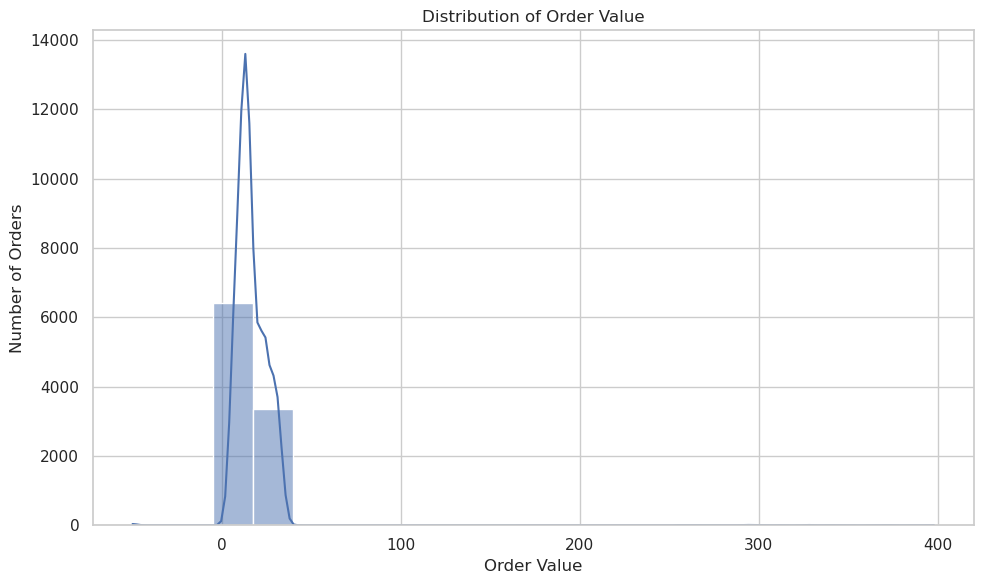

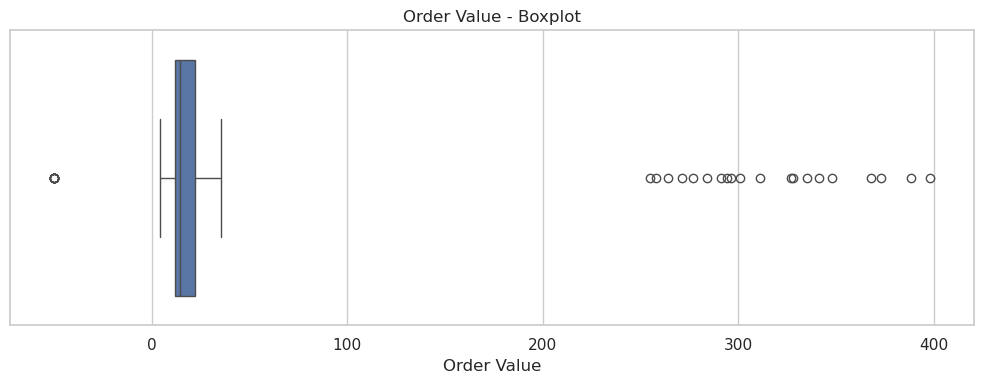

In [15]:
# ================================================================
# 13. ORDER VALUE DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="cost_of_the_order",
    bins=20,
    kde=True
)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# Order Value Boxplot
# ------------------------------------------------

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["cost_of_the_order"]
)

plt.title("Order Value - Boxplot")
plt.xlabel("Order Value")

plt.tight_layout()
plt.show()



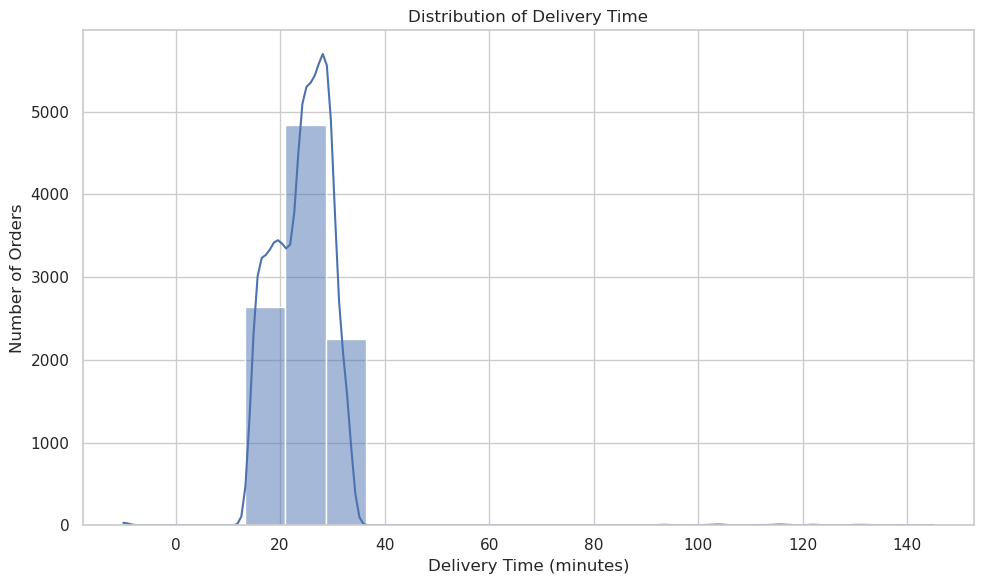

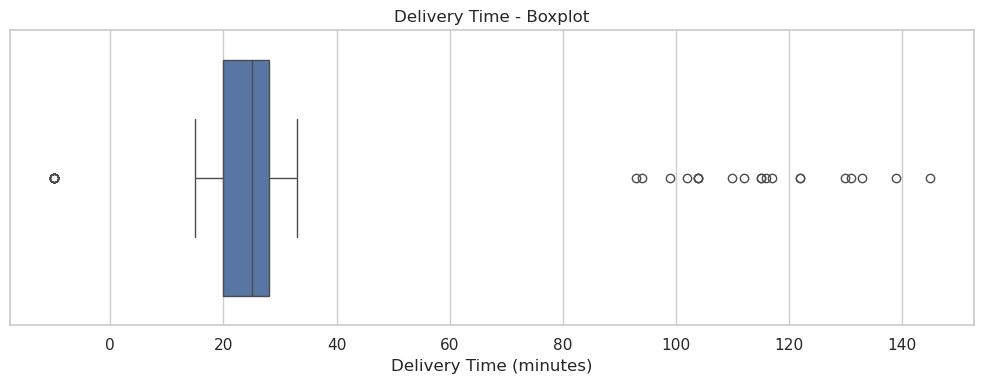

In [16]:
# ================================================================
# 14. DELIVERY TIME DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="delivery_time",
    bins=20,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# ------------------------------------------------
# Delivery Time Boxplot
# ------------------------------------------------

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["delivery_time"]
)

plt.title("Delivery Time - Boxplot")
plt.xlabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()



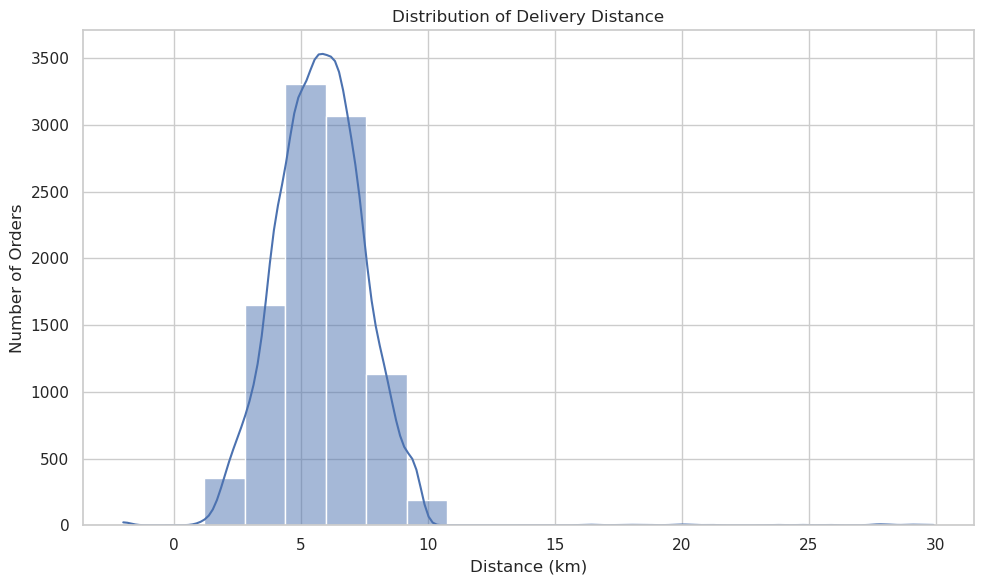

In [17]:
# ================================================================
# 15. DISTANCE DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="distance_km",
    bins=20,
    kde=True
)

plt.title("Distribution of Delivery Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


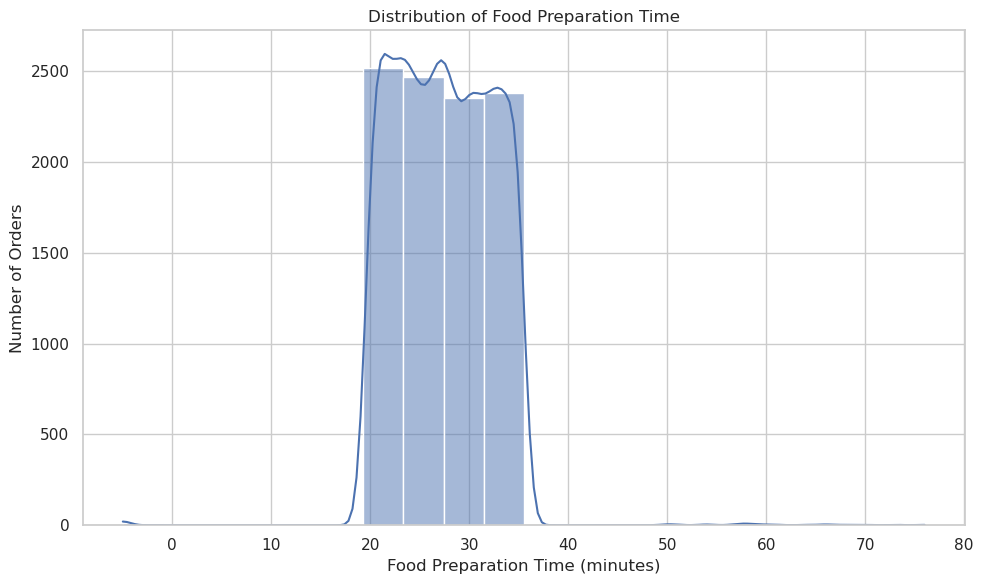

In [18]:
# ================================================================
# 16. FOOD PREPARATION TIME DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="food_preparation_time",
    bins=20,
    kde=True
)

plt.title("Distribution of Food Preparation Time")
plt.xlabel("Food Preparation Time (minutes)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()




Orders by Cuisine Type:


,Number of Orders
cuisine_type,
American,3033
Japanese,2413
Italian,1567
Chinese,1061
Indian,419
Mexican,392
Mediterranean,243
Middle Eastern,234
Southern,94


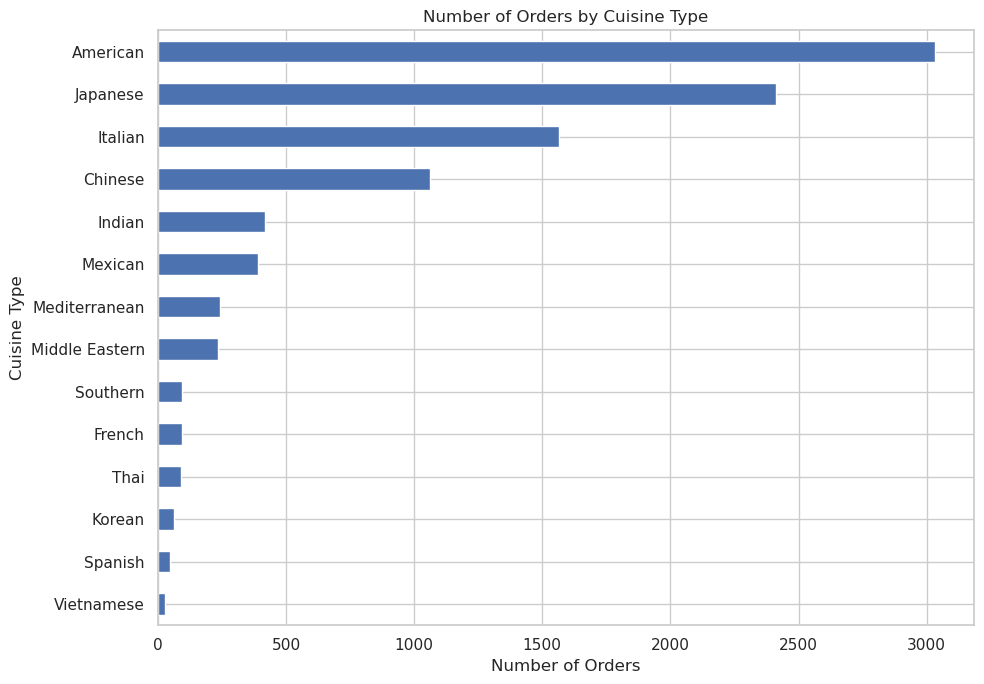

In [19]:
# ================================================================
# 17. MOST COMMON CUISINE TYPES
# ================================================================

cuisine_counts = (
    df["cuisine_type"]
    .value_counts()
)

print("\nOrders by Cuisine Type:")
display(
    cuisine_counts.to_frame("Number of Orders")
)


# ------------------------------------------------
# Cuisine Visualization
# ------------------------------------------------

plt.figure(figsize=(10, 7))

cuisine_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Orders by Cuisine Type")
plt.xlabel("Number of Orders")
plt.ylabel("Cuisine Type")

plt.tight_layout()
plt.show()




Top 10 Restaurants by Number of Orders:


,Number of Orders
restaurant_name,
Shake Shack,1163
The Meatball Shop,699
Blue Ribbon Sushi,635
Blue Ribbon Fried Chicken,482
Parm,348
RedFarm Broadway,276
RedFarm Hudson,272
TAO,256
Han Dynasty,249


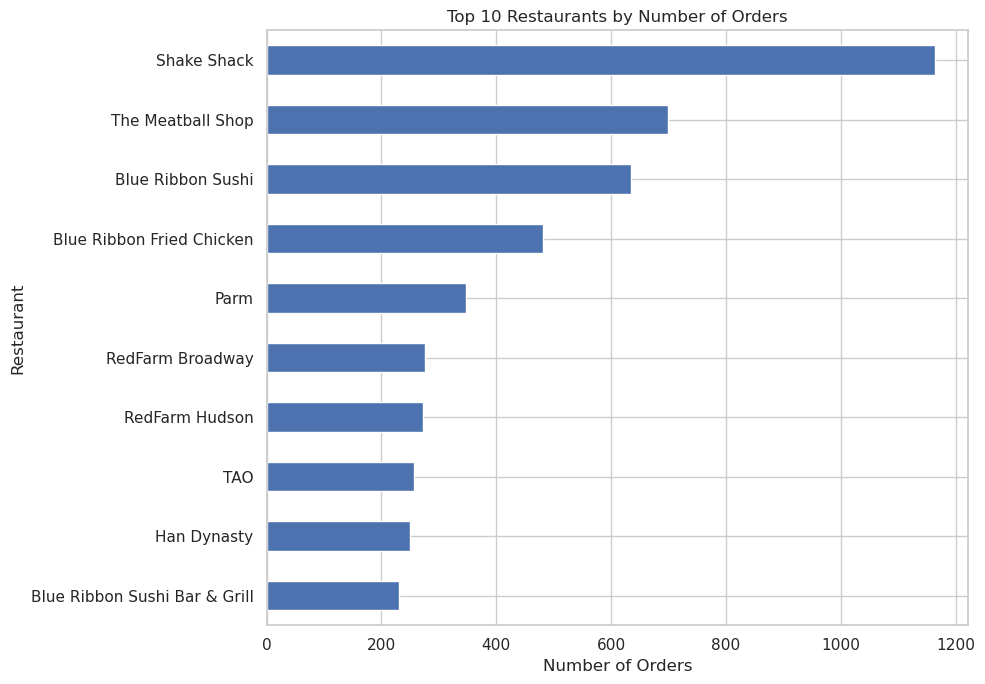

In [20]:
# ================================================================
# 18. TOP 10 RESTAURANTS
# ================================================================

restaurant_counts = (
    df["restaurant_name"]
    .value_counts()
    .head(10)
)

print("\nTop 10 Restaurants by Number of Orders:")
display(
    restaurant_counts.to_frame("Number of Orders")
)


# ------------------------------------------------
# Restaurant Visualization
# ------------------------------------------------

plt.figure(figsize=(10, 7))

restaurant_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Restaurants by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant")

plt.tight_layout()
plt.show()



Orders by Day Type:


,Number of Orders
day_of_the_week,
Weekend,7023
Weekday,2827


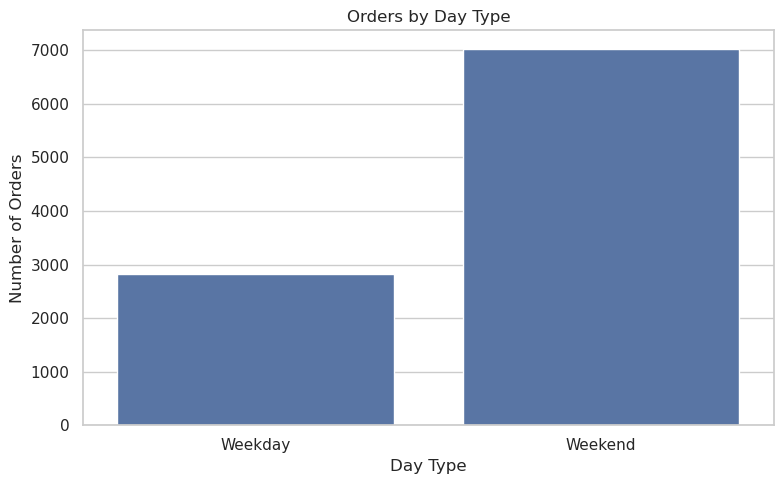

In [21]:
# 19. ORDERS BY DAY TYPE
# ================================================================

day_counts = (
    df["day_of_the_week"]
    .value_counts()
)

print("\nOrders by Day Type:")
display(
    day_counts.to_frame("Number of Orders")
)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="day_of_the_week"
)

plt.title("Orders by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


Orders by Traffic Level:


,Number of Orders
traffic,
Moderate,4615
Low,2796
Heavy,2339


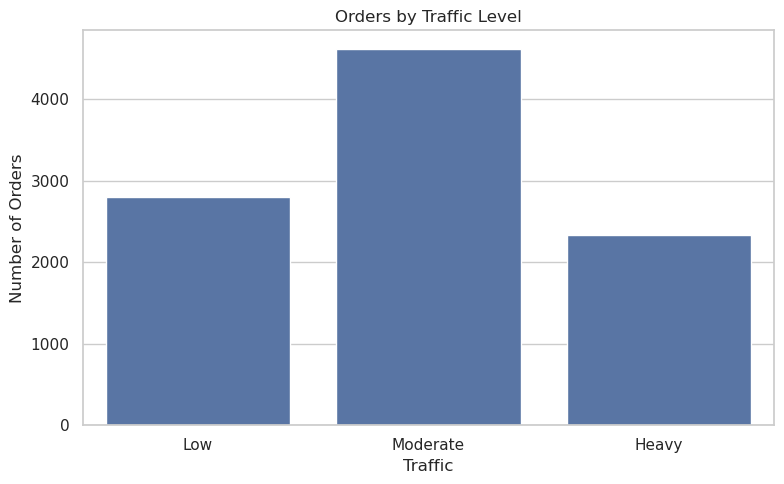

In [22]:
# ================================================================
# 20. ORDERS BY TRAFFIC LEVEL
# ================================================================

traffic_counts = (
    df["traffic"]
    .value_counts()
)

print("\nOrders by Traffic Level:")
display(
    traffic_counts.to_frame("Number of Orders")
)


plt.figure(figsize=(8, 5))

traffic_order = [
    "Low",
    "Moderate",
    "Heavy"
]

sns.countplot(
    data=df,
    x="traffic",
    order=traffic_order
)

plt.title("Orders by Traffic Level")
plt.xlabel("Traffic")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()



Orders by Weather:


,Number of Orders
weather,
Clear,5517
Cloudy,2529
Rainy,1724


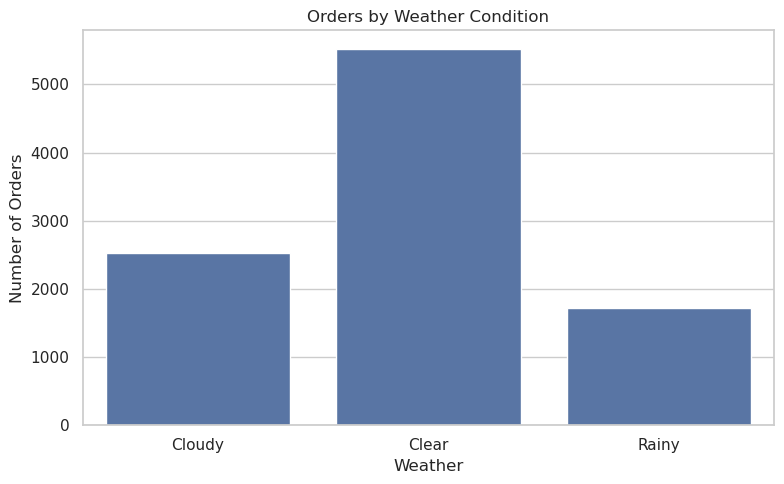

In [23]:
# ================================================================
# 21. ORDERS BY WEATHER
# ================================================================

weather_counts = (
    df["weather"]
    .value_counts()
)

print("\nOrders by Weather:")
display(
    weather_counts.to_frame("Number of Orders")
)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="weather"
)

plt.title("Orders by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()



Delivery Time by Traffic:


,Count,Mean,Median,Minimum,Maximum
traffic,,,,,
Heavy,2324,27.01,28.0,-10.0,139.0
Low,2768,21.65,21.0,-10.0,130.0
Moderate,4559,24.62,25.0,-10.0,145.0


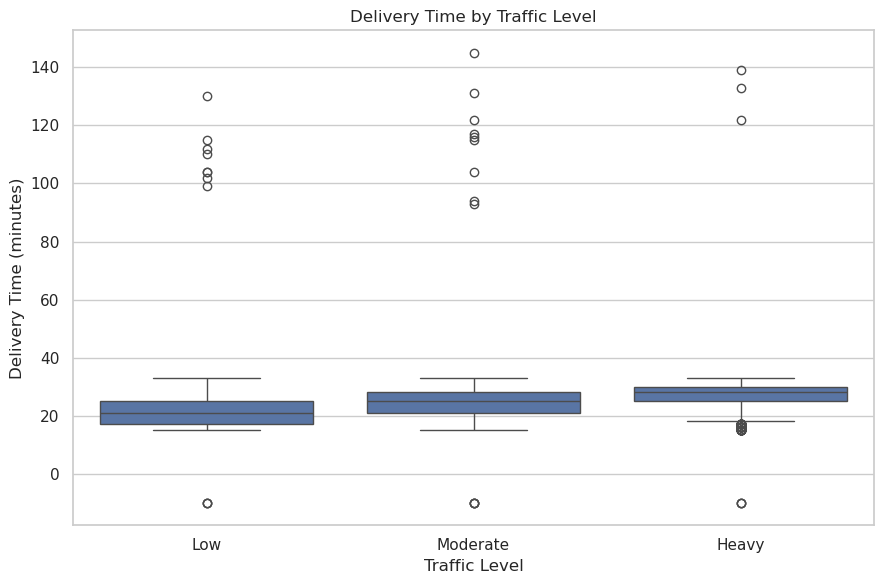

In [24]:
# ================================================================
# 22. BIVARIATE ANALYSIS
# ================================================================

# 26.1 TRAFFIC VS DELIVERY TIME
# ================================================================

traffic_delivery = (
    df.groupby("traffic")["delivery_time"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

print("\nDelivery Time by Traffic:")
display(traffic_delivery)


# ------------------------------------------------
# Boxplot
# ------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="traffic",
    y="delivery_time",
    order=["Low", "Moderate", "Heavy"]
)

plt.title("Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()



Delivery Time by Weather:


,Count,Mean,Median,Minimum,Maximum
weather,,,,,
Clear,5461,23.65,24.0,-10.0,145.0
Cloudy,2504,24.81,25.0,-10.0,139.0
Rainy,1707,25.82,27.0,-10.0,122.0


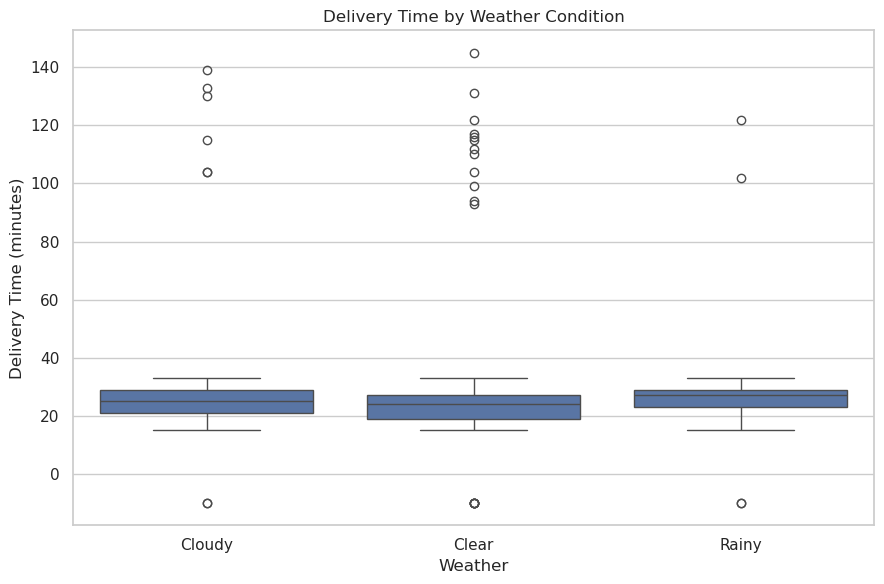

In [25]:
# ================================================================
# 23. WEATHER VS DELIVERY TIME
# ================================================================

weather_delivery = (
    df.groupby("weather")["delivery_time"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

print("\nDelivery Time by Weather:")
display(weather_delivery)


plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="weather",
    y="delivery_time"
)

plt.title("Delivery Time by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()




Correlation between Distance and Delivery Time: 0.378


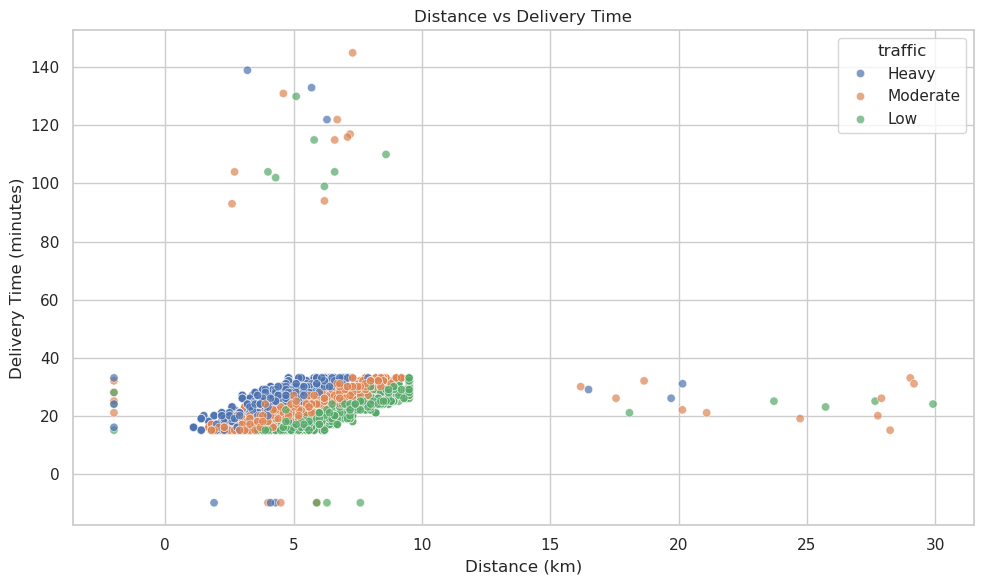

In [26]:
# ================================================================
# 24. DISTANCE VS DELIVERY TIME
# ================================================================

distance_delivery_corr = (
    df["distance_km"]
    .corr(df["delivery_time"])
)

print(
    "\nCorrelation between Distance and Delivery Time:",
    round(distance_delivery_corr, 3)
)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="delivery_time",
    hue="traffic",
    alpha=0.7
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()



Correlation between Distance and Order Value: -0.009


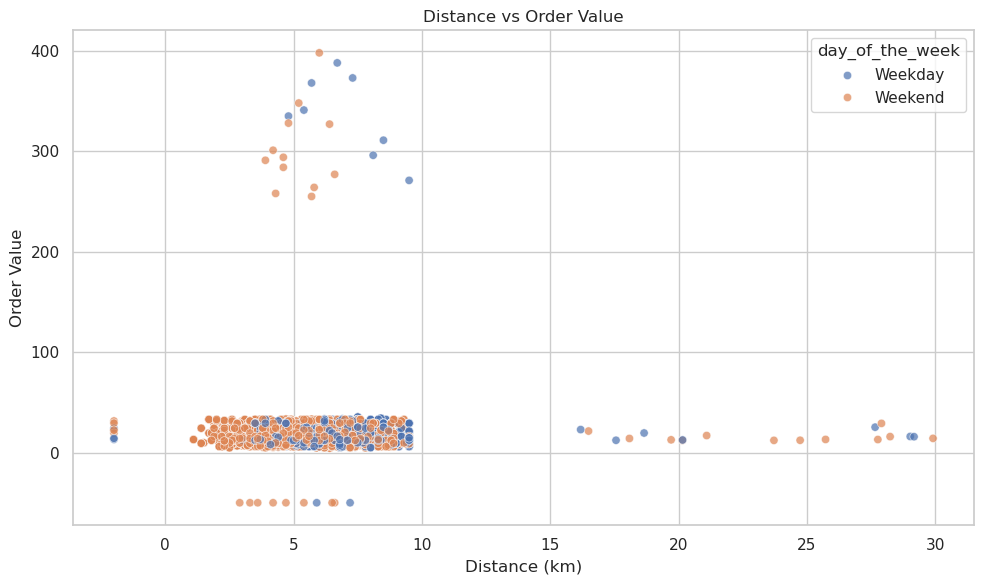

In [27]:
# ================================================================
# 25. DISTANCE VS ORDER VALUE
# ================================================================

distance_order_corr = (
    df["distance_km"]
    .corr(df["cost_of_the_order"])
)

print(
    "\nCorrelation between Distance and Order Value:",
    round(distance_order_corr, 3)
)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="cost_of_the_order",
    hue="day_of_the_week",
    alpha=0.7
)

plt.title("Distance vs Order Value")
plt.xlabel("Distance (km)")
plt.ylabel("Order Value")

plt.tight_layout()
plt.show()


Correlation between Food Preparation Time and Delivery Time: 0.0


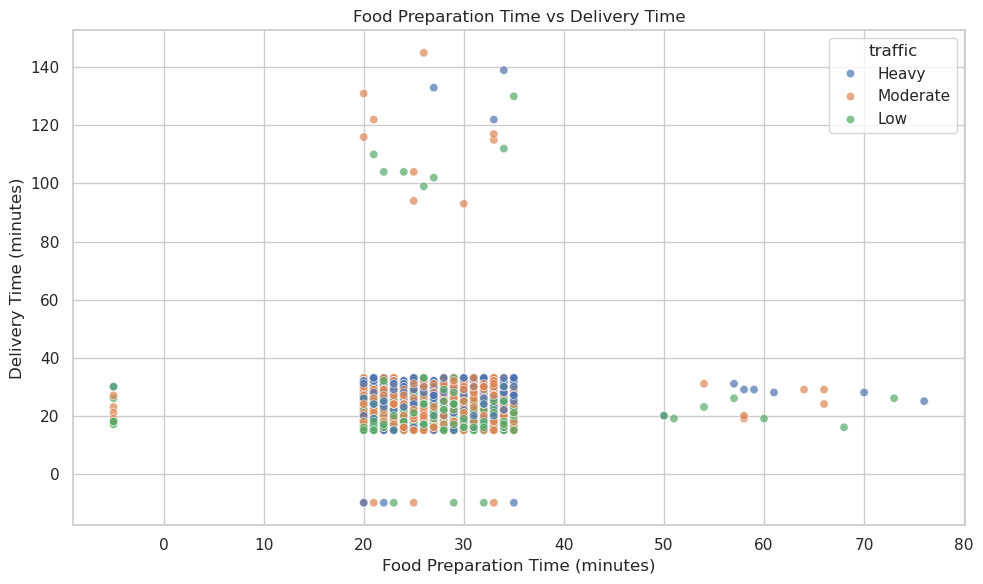

In [28]:
# ================================================================
# 26. FOOD PREPARATION TIME VS DELIVERY TIME
# ================================================================

preparation_delivery_corr = (
    df["food_preparation_time"]
    .corr(df["delivery_time"])
)

print(
    "\nCorrelation between Food Preparation Time and Delivery Time:",
    round(preparation_delivery_corr, 3)
)


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="food_preparation_time",
    y="delivery_time",
    hue="traffic",
    alpha=0.7
)

plt.title("Food Preparation Time vs Delivery Time")
plt.xlabel("Food Preparation Time (minutes)")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()



Delivery Time by Day Type:


,Count,Mean,Median,Minimum,Maximum
day_of_the_week,,,,,
Weekday,2801,28.56,28.0,24.0,145.0
Weekend,6950,22.64,22.0,-10.0,139.0


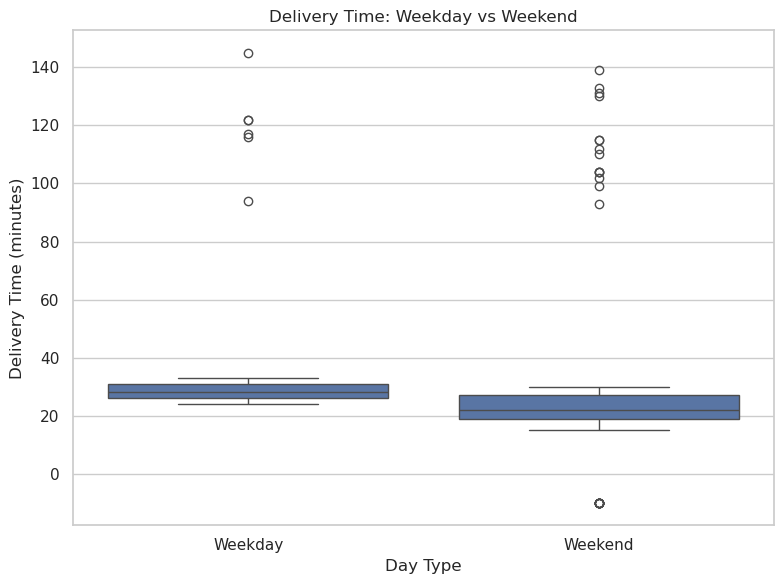

In [29]:
# ================================================================
# 26. WEEKDAY VS WEEKEND DELIVERY TIME
# ================================================================

day_delivery = (
    df.groupby("day_of_the_week")["delivery_time"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

print("\nDelivery Time by Day Type:")
display(day_delivery)


plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="day_of_the_week",
    y="delivery_time"
)

plt.title("Delivery Time: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Delivery Time (minutes)")

plt.tight_layout()
plt.show()



Correlation Matrix:


,cost_of_the_order,food_preparation_time,delivery_time,distance_km,rating
cost_of_the_order,1.00,0.01,0.01,-0.01,0.04
food_preparation_time,0.01,1.00,0.00,-0.02,-0.00
delivery_time,0.01,0.00,1.00,0.38,-0.01
distance_km,-0.01,-0.02,0.38,1.00,-0.03
rating,0.04,-0.00,-0.01,-0.03,1.00


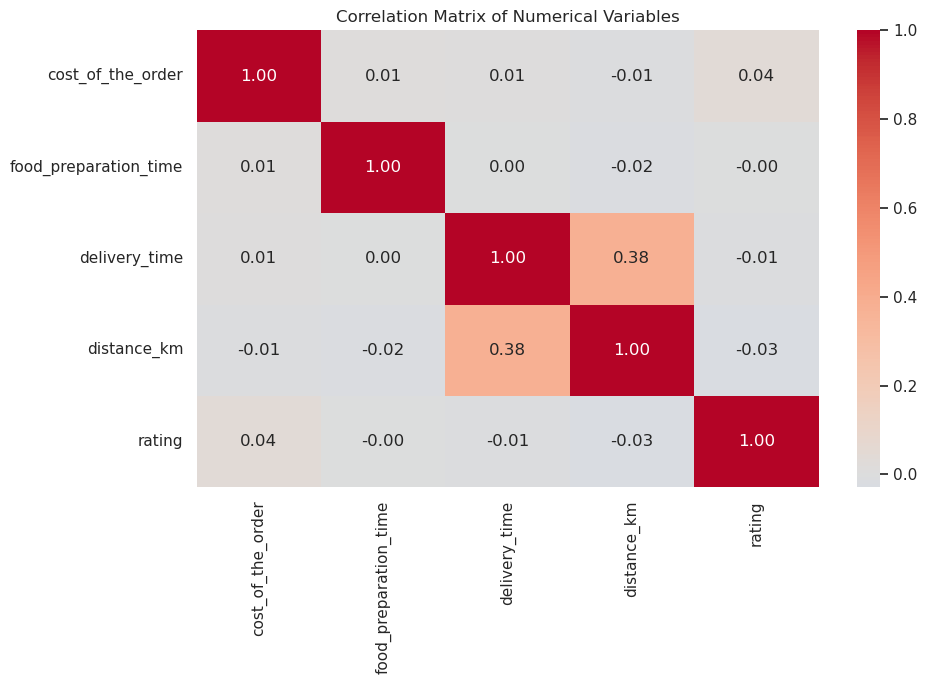

In [30]:
# ================================================================
# 27. MULTIVARIATE ANALYSIS
# ================================================================

# 28. CORRELATION MATRIX
# ================================================================

correlation_columns = [
    "cost_of_the_order",
    "food_preparation_time",
    "delivery_time",
    "distance_km",
    "rating"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

print("\nCorrelation Matrix:")
display(
    correlation_matrix.round(2)
)


# ------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()



Average Delivery Time by Traffic and Weather:


weather,Clear,Cloudy,Rainy
traffic,,,
Low,21.39,21.42,23.03
Moderate,24.06,25.03,25.76
Heavy,26.16,27.48,28.40


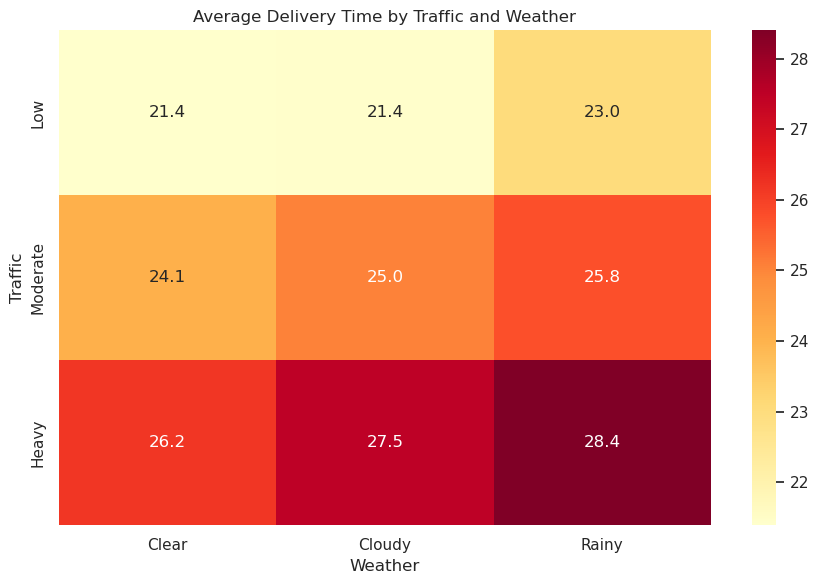

In [31]:
# ================================================================
# 29. TRAFFIC + WEATHER + DELIVERY TIME
# ================================================================

traffic_weather = pd.pivot_table(
    df,
    values="delivery_time",
    index="traffic",
    columns="weather",
    aggfunc="mean"
)

# Put traffic into logical order
traffic_weather = traffic_weather.reindex(
    index=["Low", "Moderate", "Heavy"]
)

print("\nAverage Delivery Time by Traffic and Weather:")
display(
    traffic_weather.round(2)
)


# ------------------------------------------------
# Heatmap
# ------------------------------------------------

plt.figure(figsize=(9, 6))

sns.heatmap(
    traffic_weather,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title(
    "Average Delivery Time by Traffic and Weather"
)

plt.xlabel("Weather")
plt.ylabel("Traffic")

plt.tight_layout()
plt.show()


In [32]:
# ================================================================
# 30. CUISINE + DELIVERY TIME + ORDER VALUE
# ================================================================

cuisine_analysis = (
    df.groupby("cuisine_type")
    .agg(
        Number_of_Orders=("order_id", "count"),
        Average_Order_Value=("cost_of_the_order", "mean"),
        Average_Delivery_Time=("delivery_time", "mean"),
        Average_Distance=("distance_km", "mean")
    )
    .sort_values(
        "Average_Delivery_Time",
        ascending=False
    )
)

print("\nCuisine-Level Analysis:")
display(
    cuisine_analysis.round(2)
)



Cuisine-Level Analysis:


,Number_of_Orders,Average_Order_Value,Average_Delivery_Time,Average_Distance
cuisine_type,,,,
French,93,20.12,27.17,5.66
Vietnamese,27,13.66,26.67,6.30
Italian,1567,17.00,24.91,5.80
Southern,94,19.54,24.70,5.81
Thai,92,18.61,24.49,5.78
Mexican,392,17.87,24.37,5.66
American,3033,16.75,24.28,5.78
Spanish,49,19.63,24.24,5.91
Chinese,1061,17.31,24.21,5.76


In [33]:
# ================================================================
# 31. DAY + TRAFFIC + DELIVERY TIME
# ================================================================

day_traffic_analysis = (
    df.groupby(
        ["day_of_the_week", "traffic"]
    )["delivery_time"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median"
    )
    .round(2)
)

print("\nDelivery Time by Day and Traffic:")
display(day_traffic_analysis)




Delivery Time by Day and Traffic:


Count   Mean  Median
day_of_the_week traffic                       
Weekday         Heavy       958  29.50    30.0
                Low         383  26.70    26.0
                Moderate   1431  28.43    28.0
Weekend         Heavy      1366  25.26    26.0
                Low        2385  20.84    20.0
                Moderate   3128  22.88    23.0

In [34]:
# ================================================================
# 32. OUTLIER ANALYSIS
# ================================================================


# Function to identify outliers
# ------------------------------------------------

def find_outliers(data, column):

    # First quartile
    Q1 = data[column].quantile(0.25)

    # Third quartile
    Q3 = data[column].quantile(0.75)

    # Interquartile range
    IQR = Q3 - Q1

    # Lower boundary
    lower_bound = Q1 - 1.5 * IQR

    # Upper boundary
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return (
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outliers
    )


In [35]:
# ================================================================
# 33. OUTLIER ANALYSIS FOR NUMERICAL VARIABLES
# ================================================================

outlier_columns = [
    "cost_of_the_order",
    "food_preparation_time",
    "delivery_time",
    "distance_km"
]

outlier_results = []

for column in outlier_columns:

    Q1, Q3, IQR, lower, upper, outliers = (
        find_outliers(df, column)
    )

    outlier_results.append({

        "Variable": column,

        "Q1": Q1,

        "Q3": Q3,

        "IQR": IQR,

        "Lower Bound": lower,

        "Upper Bound": upper,

        "Outlier Count": len(outliers)
    })


# Convert results into DataFrame
outlier_table = pd.DataFrame(
    outlier_results
)

print("\nOutlier Summary:")
display(
    outlier_table.round(2)
)




Outlier Summary:


,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,cost_of_the_order,12.08,22.31,10.23,-3.26,37.66,30
1,food_preparation_time,23.00,31.00,8.00,11.00,43.00,30
2,delivery_time,20.00,28.00,8.00,8.00,40.00,30
3,distance_km,4.60,6.90,2.30,1.15,10.35,34


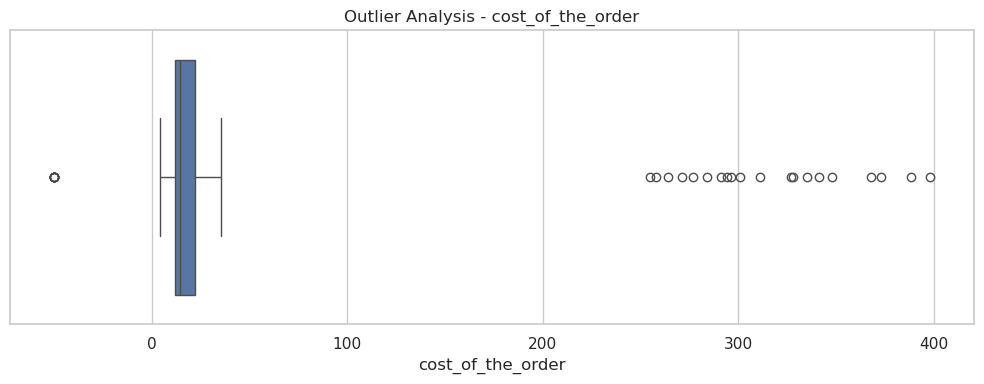

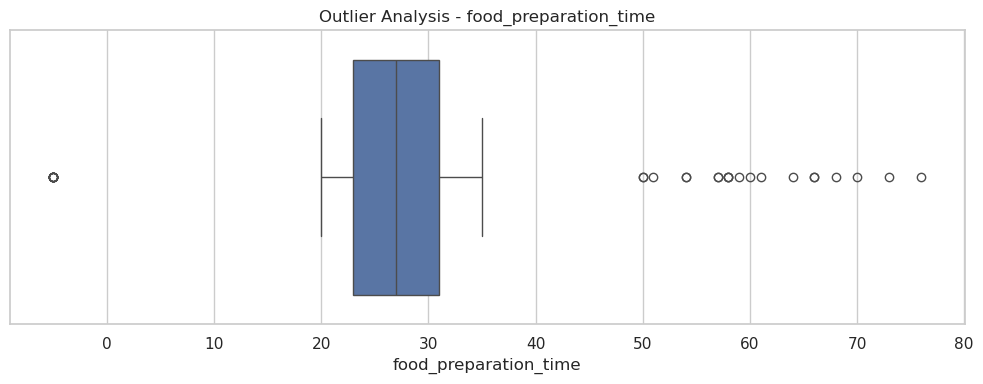

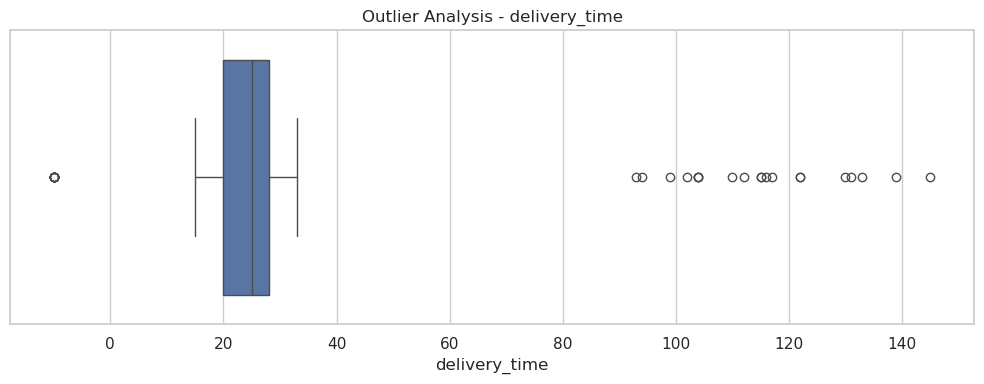

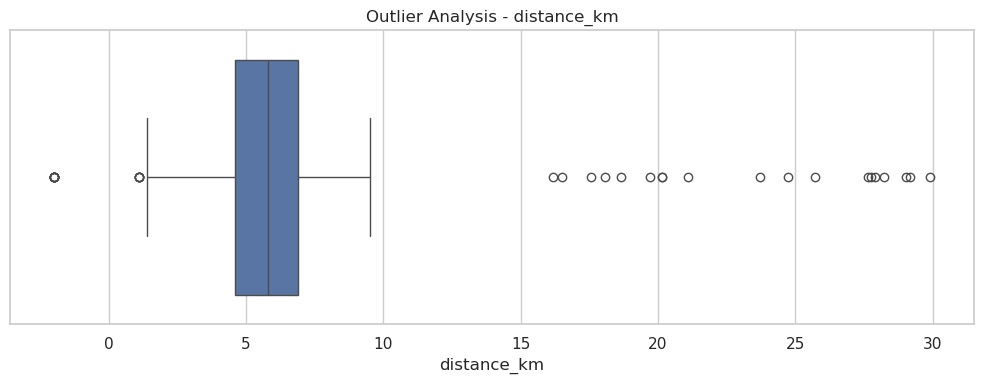

In [36]:
# ================================================================
# 34. OUTLIER BOXPLOTS
# ================================================================

for column in outlier_columns:

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"Outlier Analysis - {column}"
    )

    plt.xlabel(column)

    plt.tight_layout()
    plt.show()



In [37]:
# ================================================================
# 35. DISPLAY ACTUAL OUTLIER RECORDS
# ================================================================

for column in outlier_columns:

    Q1, Q3, IQR, lower, upper, outliers = (
        find_outliers(df, column)
    )

    print("\n" + "=" * 70)

    print(
        "OUTLIER ANALYSIS FOR:",
        column
    )

    print(
        "Number of outliers:",
        len(outliers)
    )

    if len(outliers) > 0:

        columns_to_display = [
            "order_id",
            "restaurant_name",
            "cost_of_the_order",
            "food_preparation_time",
            "delivery_time",
            "distance_km",
            "traffic",
            "weather"
        ]

        # Only display columns that exist
        columns_to_display = [
            col for col in columns_to_display
            if col in df.columns
        ]

        display(
            outliers[columns_to_display]
        )

    else:

        print(
            "No outliers detected using the IQR method."
        )


OUTLIER ANALYSIS FOR: cost_of_the_order
Number of outliers: 30


,order_id,restaurant_name,cost_of_the_order,food_preparation_time,delivery_time,distance_km,traffic,weather
67,9567,Yama Japanese Restaurant,-50.0,30.0,16.0,3.3,Moderate,Clear
228,1999,Waverly Diner,398.0,25.0,21.0,6.0,Low,Rainy
282,2041,Parm,335.0,32.0,28.0,4.8,Heavy,Cloudy
297,4718,NaN,368.0,28.0,28.0,5.7,Moderate,Cloudy
437,1034,Parm,296.0,30.0,24.0,8.1,Low,Clear
1010,4894,Mission Cantina,301.0,31.0,18.0,4.2,Moderate,Clear
1083,3656,Parm,-50.0,23.0,30.0,5.4,Heavy,Clear
2085,7470,Bareburger,-50.0,33.0,18.0,3.6,Moderate,Clear
2557,7596,RedFarm Broadway,277.0,24.0,27.0,6.6,Moderate,Rainy
2740,7299,ilili Restaurant,311.0,22.0,33.0,8.5,Moderate,Clear



OUTLIER ANALYSIS FOR: food_preparation_time
Number of outliers: 30


,order_id,restaurant_name,cost_of_the_order,food_preparation_time,delivery_time,distance_km,traffic,weather
30,5736,The Meatball Shop,12.18,50.0,20.0,2.6,Heavy,Clear
99,2338,V-Nam Cafe,12.08,51.0,19.0,6.4,Low,Clear
726,9291,Blue Ribbon Sushi Bar & Grill,16.54,-5.0,17.0,5.5,Low,Cloudy
942,9184,Cafe Mogador,6.69,-5.0,30.0,4.5,Heavy,Rainy
1320,2040,The Meatball Shop,13.00,-5.0,26.0,8.1,Low,Rainy
1576,9279,Cho Dang Gol,12.18,73.0,26.0,8.6,Low,Clear
1821,1570,RedFarm Broadway,31.43,-5.0,23.0,5.0,Moderate,Cloudy
1959,8979,Sarabeth's Restaurant,15.91,57.0,31.0,5.9,Heavy,Clear
2836,66,Ravagh Persian Grill,16.93,-5.0,21.0,5.8,Moderate,Clear
2994,1754,The Meatball Shop,9.65,70.0,28.0,5.4,Heavy,Clear



OUTLIER ANALYSIS FOR: delivery_time
Number of outliers: 30


,order_id,restaurant_name,cost_of_the_order,food_preparation_time,delivery_time,distance_km,traffic,weather
70,159,RedFarm Hudson,5.82,22.0,104.0,6.6,Low,Clear
393,1193,Shake Shack,14.02,26.0,99.0,6.2,Low,Clear
588,349,Parm,5.92,21.0,110.0,8.6,Low,Clear
798,9743,Hill Country Fried Chicken,14.12,25.0,104.0,2.7,Moderate,Cloudy
841,9636,Vanessa's Dumplings,20.23,33.0,-10.0,4.0,Moderate,Clear
1104,1459,Shake Shack,14.94,33.0,122.0,6.3,Heavy,Clear
1706,3155,RedFarm Broadway,6.79,33.0,115.0,6.6,Moderate,Cloudy
2354,1107,Sushi of Gari Tribeca,9.55,35.0,-10.0,4.3,Heavy,Clear
2726,8251,Blue Ribbon Sushi,12.23,20.0,-10.0,5.9,Moderate,Clear
3084,1323,TAO,8.05,26.0,145.0,7.3,Moderate,Clear



OUTLIER ANALYSIS FOR: distance_km
Number of outliers: 34


,order_id,restaurant_name,cost_of_the_order,food_preparation_time,delivery_time,distance_km,traffic,weather
296,8761,Blue Ribbon Fried Chicken,12.18,32.0,22.0,20.146808,Moderate,Clear
826,2534,Shake Shack,14.02,26.0,21.0,18.084580,Low,Clear
839,6621,Blue Ribbon Sushi Bar & Grill,14.12,21.0,24.0,29.913851,Low,Clear
939,3024,CafÃƒÅ’Ã‚Â© China,21.83,32.0,15.0,-2.000000,Low,Clear
991,1914,Cafe Mogador,25.27,30.0,25.0,27.657372,Low,Clear
1171,5215,Blue Ribbon Fried Chicken,12.23,33.0,26.0,17.561731,Moderate,Cloudy
1215,3279,Shake Shack,31.43,31.0,24.0,-2.000000,Low,Rainy
1221,296,Blue Ribbon Fried Chicken,12.52,24.0,31.0,20.155332,Heavy,Clear
1308,5838,Blue Ribbon Brooklyn,24.20,22.0,32.0,-2.000000,Moderate,Rainy
1351,4516,Lucky Strike,29.25,21.0,21.0,-2.000000,Moderate,Clear


In [38]:
# ================================================================
# 36. KEY INSIGHTS
# ================================================================

# Overall project metrics
# ------------------------------------------------

print("\n")
print("=" * 70)
print("OVERALL PROJECT METRICS")
print("=" * 70)

print(
    "\nTotal Orders:",
    len(df)
)

print(
    "Average Order Value:",
    round(
        df["cost_of_the_order"].mean(),
        2
    )
)

print(
    "Median Order Value:",
    round(
        df["cost_of_the_order"].median(),
        2
    )
)

print(
    "Average Delivery Time:",
    round(
        df["delivery_time"].mean(),
        2
    ),
    "minutes"
)

print(
    "Median Delivery Time:",
    round(
        df["delivery_time"].median(),
        2
    ),
    "minutes"
)

print(
    "Average Distance:",
    round(
        df["distance_km"].mean(),
        2
    ),
    "km"
)

print(
    "Average Food Preparation Time:",
    round(
        df["food_preparation_time"].mean(),
        2
    ),
    "minutes"
)


# ================================================================
# 43. FIND MOST COMMON CUISINE
# ================================================================

top_cuisine = (
    df["cuisine_type"]
    .value_counts()
    .idxmax()
)

top_cuisine_orders = (
    df["cuisine_type"]
    .value_counts()
    .max()
)

print(
    "\nInsight 1:"
)

print(
    f"{top_cuisine} is the most frequently ordered cuisine "
    f"with {top_cuisine_orders} orders."
)



OVERALL PROJECT METRICS

Total Orders: 9850
Average Order Value: 17.03
Median Order Value: 14.31
Average Delivery Time: 24.34 minutes
Median Delivery Time: 25.0 minutes
Average Distance: 5.77 km
Average Food Preparation Time: 27.44 minutes

Insight 1:
American is the most frequently ordered cuisine with 3033 orders.


In [39]:
# ================================================================
# 37. FIND TRAFFIC WITH HIGHEST DELIVERY TIME
# ================================================================

traffic_average = (
    df.groupby("traffic")["delivery_time"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(
    "\nAverage Delivery Time by Traffic:"
)

display(
    traffic_average.round(2)
)

print(
    "Insight 2:"
)

print(
    f"{traffic_average.idxmax()} traffic has the highest "
    f"average delivery time of "
    f"{traffic_average.max():.2f} minutes."
)



Average Delivery Time by Traffic:


traffic
Heavy       27.01
Moderate    24.62
Low         21.65
Name: delivery_time, dtype: float64

Insight 2:
Heavy traffic has the highest average delivery time of 27.01 minutes.


In [40]:
# ================================================================
# 38. FIND TRAFFIC WITH HIGHEST DELIVERY TIME
# ================================================================

traffic_average = (
    df.groupby("traffic")["delivery_time"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(
    "\nAverage Delivery Time by Traffic:"
)

display(
    traffic_average.round(2)
)

print(
    "Insight 2:"
)

print(
    f"{traffic_average.idxmax()} traffic has the highest "
    f"average delivery time of "
    f"{traffic_average.max():.2f} minutes."
)



Average Delivery Time by Traffic:


traffic
Heavy       27.01
Moderate    24.62
Low         21.65
Name: delivery_time, dtype: float64

Insight 2:
Heavy traffic has the highest average delivery time of 27.01 minutes.


In [41]:
# ================================================================
# 39. FIND TRAFFIC WITH HIGHEST DELIVERY TIME
# ================================================================

traffic_average = (
    df.groupby("traffic")["delivery_time"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(
    "\nAverage Delivery Time by Traffic:"
)

display(
    traffic_average.round(2)
)

print(
    "Insight 2:"
)

print(
    f"{traffic_average.idxmax()} traffic has the highest "
    f"average delivery time of "
    f"{traffic_average.max():.2f} minutes."
)



Average Delivery Time by Traffic:


traffic
Heavy       27.01
Moderate    24.62
Low         21.65
Name: delivery_time, dtype: float64

Insight 2:
Heavy traffic has the highest average delivery time of 27.01 minutes.


In [42]:
# ================================================================
# 40. FIND WEATHER WITH HIGHEST DELIVERY TIME
# ================================================================

weather_average = (
    df.groupby("weather")["delivery_time"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(
    "\nAverage Delivery Time by Weather:"
)

display(
    weather_average.round(2)
)

print(
    "Insight 3:"
)

print(
    f"{weather_average.idxmax()} weather has the highest "
    f"average delivery time of "
    f"{weather_average.max():.2f} minutes."
)


Average Delivery Time by Weather:


weather
Rainy     25.82
Cloudy    24.81
Clear     23.65
Name: delivery_time, dtype: float64

Insight 3:
Rainy weather has the highest average delivery time of 25.82 minutes.


In [43]:
# ================================================================
# 41. FIND DAY TYPE WITH HIGHEST DELIVERY TIME
# ================================================================

day_average = (
    df.groupby("day_of_the_week")["delivery_time"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(
    "\nAverage Delivery Time by Day Type:"
)

display(
    day_average.round(2)
)

print(
    "Insight 4:"
)

print(
    f"{day_average.idxmax()} orders have the highest "
    f"average delivery time of "
    f"{day_average.max():.2f} minutes."
)



Average Delivery Time by Day Type:


day_of_the_week
Weekday    28.56
Weekend    22.64
Name: delivery_time, dtype: float64

Insight 4:
Weekday orders have the highest average delivery time of 28.56 minutes.


In [44]:
# ================================================================
# 42. DISTANCE AND DELIVERY TIME CORRELATION
# ================================================================

distance_delivery_corr = (
    df["distance_km"]
    .corr(
        df["delivery_time"]
    )
)

print(
    "\nInsight 5:"
)

print(
    f"The correlation between distance and delivery time "
    f"is {distance_delivery_corr:.3f}."
)




Insight 5:
The correlation between distance and delivery time is 0.378.


In [45]:

# ================================================================
# 43. FOOD PREPARATION AND DELIVERY TIME CORRELATION
# ================================================================

preparation_delivery_corr = (
    df["food_preparation_time"]
    .corr(
        df["delivery_time"]
    )
)

print(
    "\nInsight 6:"
)

print(
    f"The correlation between food preparation time and "
    f"delivery time is {preparation_delivery_corr:.3f}."
)



Insight 6:
The correlation between food preparation time and delivery time is 0.000.


In [46]:

# ================================================================
# 45. ORDER VALUE AND DELIVERY TIME CORRELATION
# ================================================================

order_delivery_corr = (
    df["cost_of_the_order"]
    .corr(
        df["delivery_time"]
    )
)

print(
    "\nInsight 7:"
)

print(
    f"The correlation between order value and delivery time "
    f"is {order_delivery_corr:.3f}."
)



Insight 7:
The correlation between order value and delivery time is 0.008.


In [47]:

# ================================================================
# 46. FINAL SUMMARY TABLE
# ================================================================

summary = pd.DataFrame({

    "Metric": [
        "Total Orders",
        "Average Order Value",
        "Median Order Value",
        "Average Delivery Time",
        "Median Delivery Time",
        "Average Distance",
        "Average Food Preparation Time",
        "Distance vs Delivery Time Correlation",
        "Preparation Time vs Delivery Time Correlation",
        "Order Value vs Delivery Time Correlation"
    ],

    "Value": [

        len(df),

        round(
            df["cost_of_the_order"].mean(),
            2
        ),

        round(
            df["cost_of_the_order"].median(),
            2
        ),

        round(
            df["delivery_time"].mean(),
            2
        ),

        round(
            df["delivery_time"].median(),
            2
        ),

        round(
            df["distance_km"].mean(),
            2
        ),

        round(
            df["food_preparation_time"].mean(),
            2
        ),

        round(
            distance_delivery_corr,
            3
        ),

        round(
            preparation_delivery_corr,
            3
        ),

        round(
            order_delivery_corr,
            3
        )
    ]
})

print("\nFINAL PROJECT SUMMARY:")
display(summary)


























FINAL PROJECT SUMMARY:


,Metric,Value
0,Total Orders,9850.000
1,Average Order Value,17.030
2,Median Order Value,14.310
3,Average Delivery Time,24.340
4,Median Delivery Time,25.000
5,Average Distance,5.770
6,Average Food Preparation Time,27.440
7,Distance vs Delivery Time Correlation,0.378
8,Preparation Time vs Delivery Time Correlation,0.000
9,Order Value vs Delivery Time Correlation,0.008
